## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [1]:
import sys

In [2]:
# Installing the libraries with the specified version.
!{sys.executable} -m pip install -U pip setuptools wheel

# Versions that work well with Python 3.12
!{sys.executable} -m pip install \
    numpy==1.26.4 \
    pandas==2.2.2 \
    scikit-learn==1.5.2 \
    matplotlib==3.8.4 \
    seaborn==0.13.2 \
    xgboost==3.0.5

!{sys.executable} -m pip install imbalanced-learn


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [61]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Import Dataset

In [4]:
easyvisa = pd.read_csv("EasyVisa.csv")

df = easyvisa.copy()

df['case_status'].unique()

array(['Denied', 'Certified'], dtype=object)

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [5]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [6]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


#### Understand the shape of the dataset

In [7]:
df.shape

(25480, 12)

#### Check the data types of the columns for the dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


#### Observation 
- only 3 columns are numeric the rest are object type
- there's no columns with null/missing value

### Checking for duplicate values

In [9]:
# let's check for duplicate values in the data
df.duplicated().sum()

0

#### Observation 
- there's no duplicate rows in the data

### Checking for missing values

In [10]:
# let's check for missing values in the data
round(df.isnull().sum() / df.isnull().count() * 100, 2)

case_id                 0.000
continent               0.000
education_of_employee   0.000
has_job_experience      0.000
requires_job_training   0.000
no_of_employees         0.000
yr_of_estab             0.000
region_of_employment    0.000
prevailing_wage         0.000
unit_of_wage            0.000
full_time_position      0.000
case_status             0.000
dtype: float64

#### Observation 
- there's no missing values in the data

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [11]:
#statistical summary of the numerical columns in the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


#### Observation
- average number of employees is 5k and maximum 600k and minimum -26 which needs to be fixed cause it's not valid
- average wage is 74k and minimum is 2.137 and maximum is 319k

#### Fixing the negative values in number of employees columns

In [12]:
#
df[df['no_of_employees'] < 0].head()
df[df['no_of_employees'] < 0].shape

# df.loc[df['no_of_employees'] < 0].shape

(33, 12)

In [13]:
# fix negative by taking the absolute value
df["no_of_employees"] = abs(df["no_of_employees"])


#### Let's check the count of each unique category in each of the categorical variables

In [14]:
#drop the column case_id since it's unique for all rows 
df.drop(columns=['case_id'], inplace=True)

# Making a list of all catrgorical variables
cat_col = list(df.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
--------------------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
--------------------------------------------------
full_time_posit

#### Observation : 
- most employees are from the continent asia
- most employees have bachelors degree

### Univariate Analysis

In [15]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

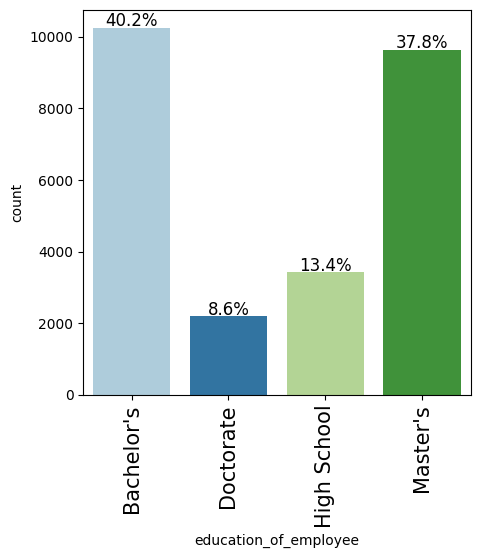

In [17]:
#
labeled_barplot(df, "education_of_employee", perc=True)


#### Observation
- most employees have Bachelor's and Master's with 40% and 37% respectively
- doctorate and hight school have the least number

#### Observations on region of employment

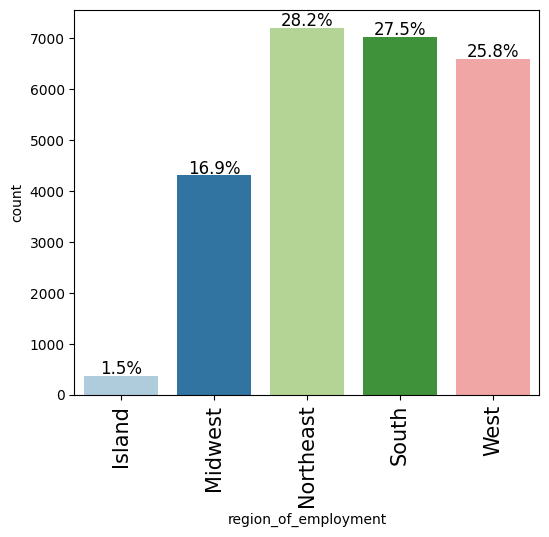

In [18]:
#
labeled_barplot(df,"region_of_employment",perc=True)

#### Observation 
- We have least number of employees from Island 
- Number of employees is fairly distributed between NorthEast, South and West

#### Observations on job experience

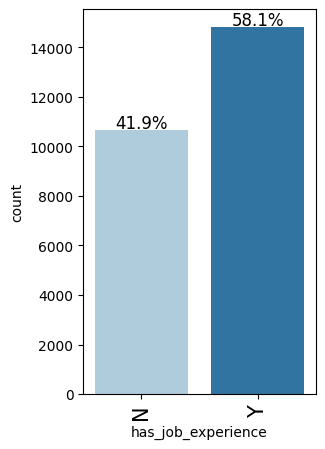

In [19]:
# df.info()
labeled_barplot(df,"has_job_experience",perc=True)


#### Observation
- ~ 40% of employees have no experience 
- ~ 60% of employees have experience

#### Observations on case status

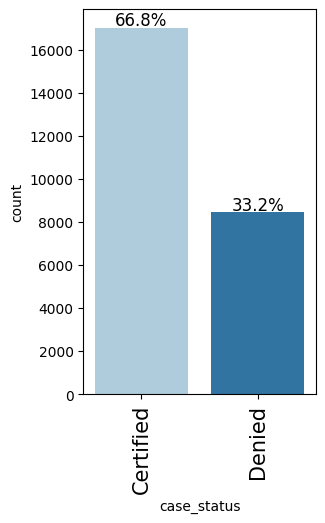

In [20]:
# df.info()
labeled_barplot(df,"case_status",perc=True)

#### Observation
- 66% of cases are certified 
- 33% of cases are denied
- we have an imbalanced dataset with certified being the majority class

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [21]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [22]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


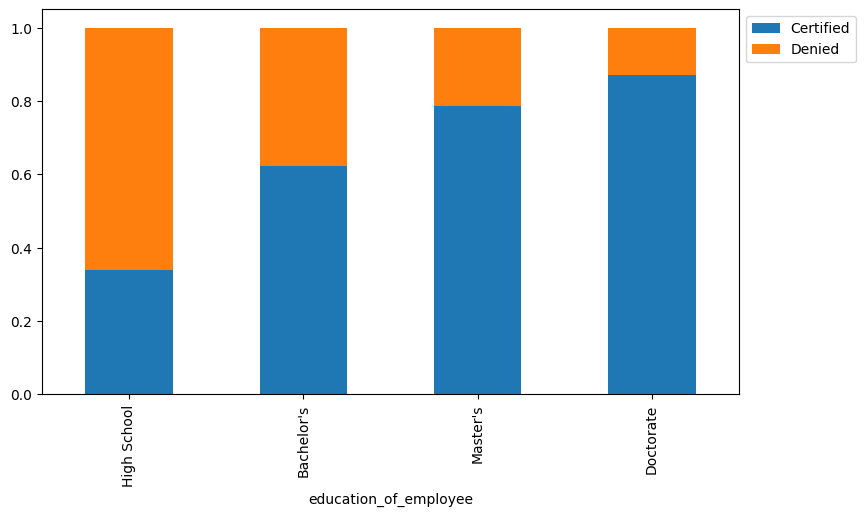

In [23]:
stacked_barplot(df, "education_of_employee", "case_status")


#### Observation
- higher education increases chance if getting visa certified
- employees with doctorate education have higher chance of getting visa certified

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


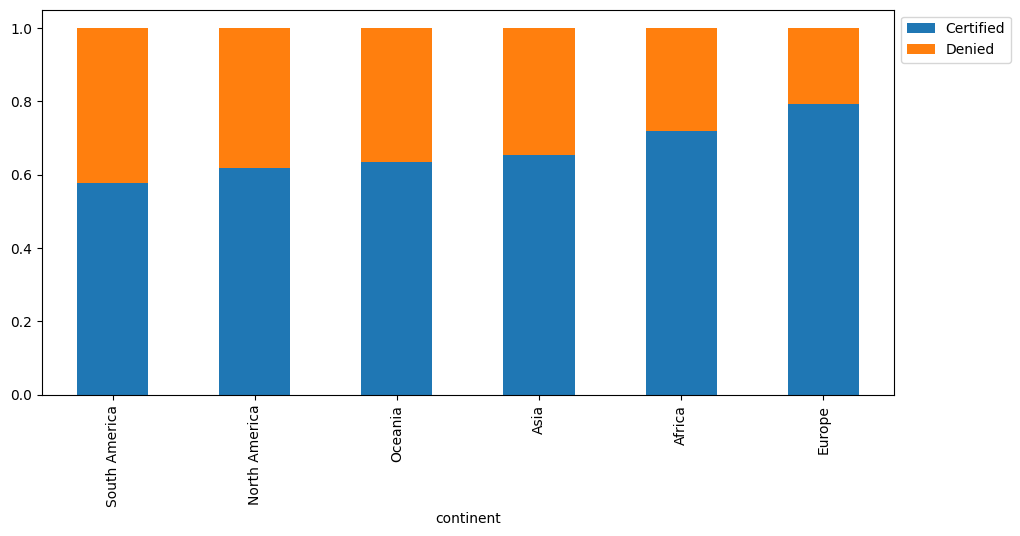

In [24]:
stacked_barplot(df, "continent", "case_status")


#### Observation 
- Europe has the highest certification rate, with nearly 80% of applicants certified.
- Africa also shows a strong certification rate, slightly above 70%.
- Asia and Oceania have moderate certification rates around 65%.
- North America and South America have relatively lower certification rates (roughly 60% or below).

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


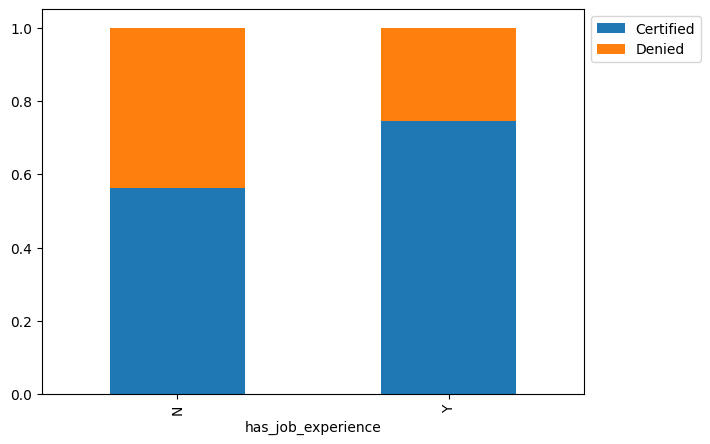

In [25]:
stacked_barplot(df, "has_job_experience", "case_status")

#### Observation 
- Applicants with job experience Have a higher chance of certifications.
- Applicants with no job experience Have a lower chance of certifications.

#### Is the prevailing wage consistent across all regions of the US?

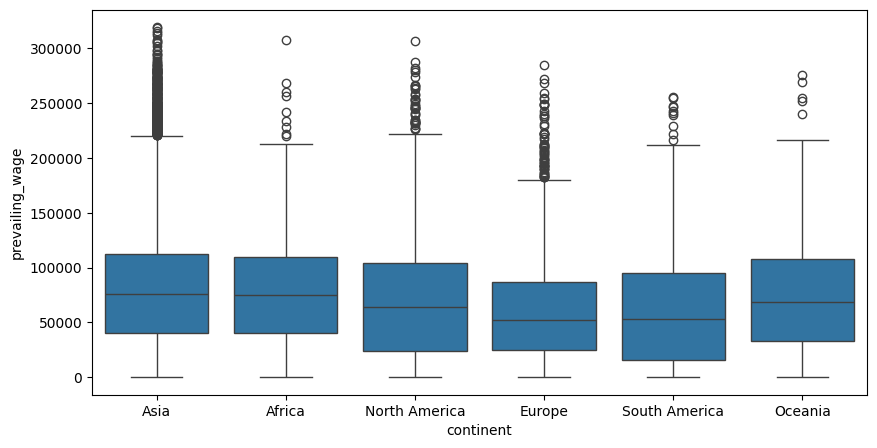

In [26]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="continent", y="prevailing_wage")
plt.show()

#### Observation
- Africa, Oceania and Asia have the highest median wages.
- Europe, North America, and South America have lower median wages.
- All regions contain outliers with very high wages, but Asia, North America, and Europe show the most extreme high-wage outliers.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

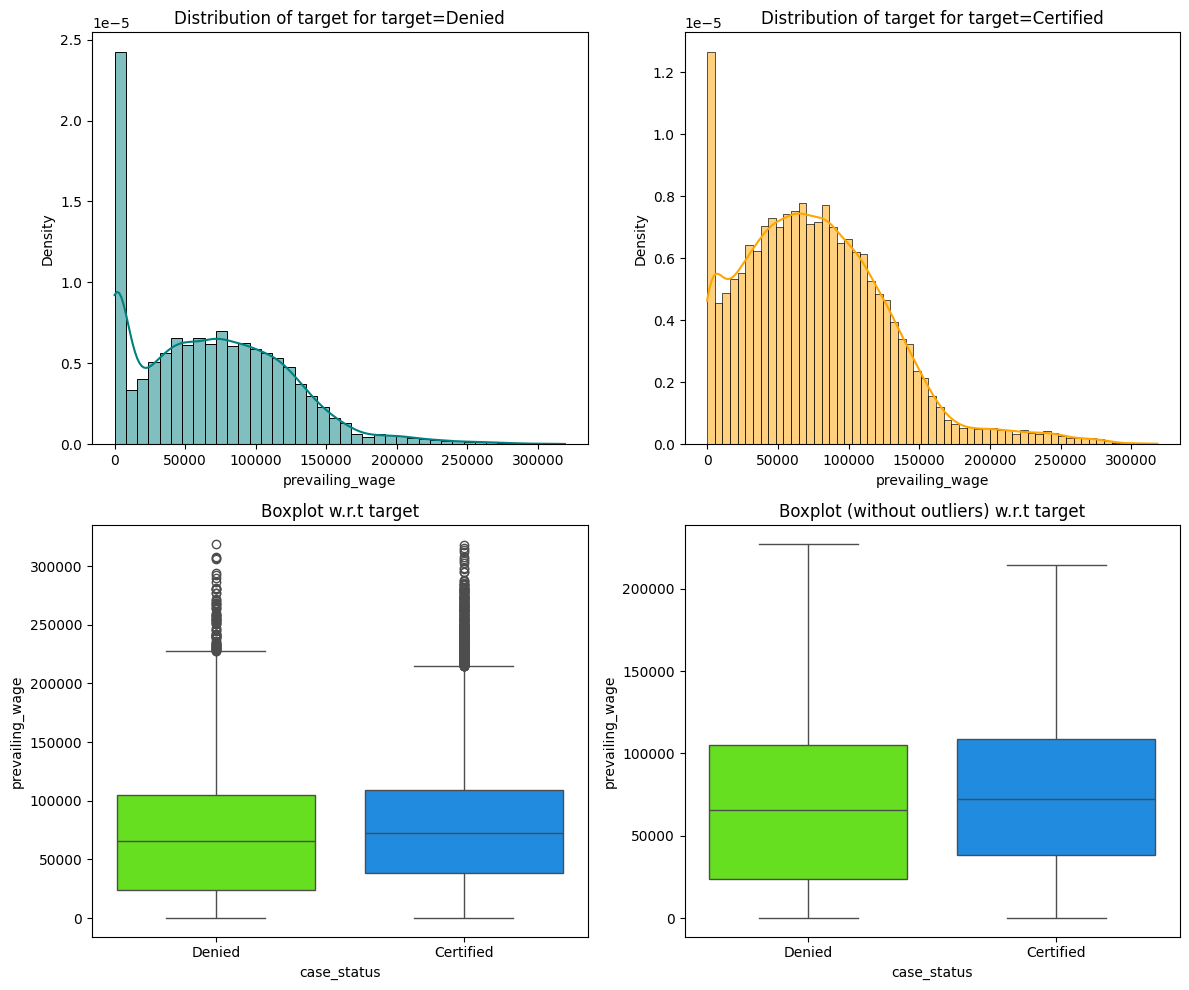

In [27]:
# plt.figure(figsize=(10, 5))
# sns.boxplot(data=df, x="case_status", y="prevailing_wage")
# plt.show()
distribution_plot_wrt_target(df,"prevailing_wage","case_status")

#### Observation
- The Denied distribution peaks at lower wage ranges (~30,000–60,000).
- The Certified distribution is slightly shifted to the right, certified cases tend to have higher prevailing wages on average.
- Both distributions are right-skewed, showing many low to mid-range wages and a few very high-wage outliers.
- Both boxplots show a similar spread, but the Certified group’s median wage is slightly higher than the Denied group’s.
- The Certified group also has more high-end outliers, suggesting higher-paying jobs are more likely to be certified.
- The Certified median remains above the Denied median.

- the overlap between the two groups shows that wage alone isn’t the sole determining factor

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


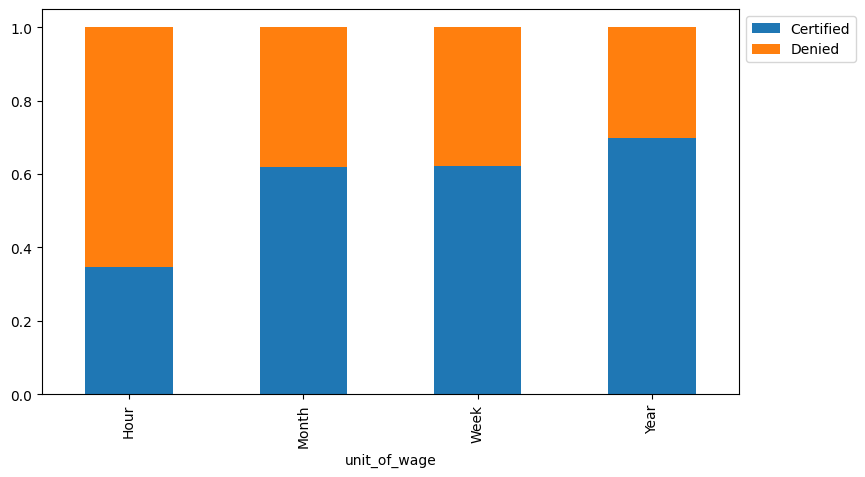

In [28]:
stacked_barplot(df,"unit_of_wage","case_status")

#### Observation 
- Hourly wage applications show a much higher denial rate
- Monthly, Weekly, and Yearly wage units show significantly higher certification rates, each around 60–70% certified.
- The Yearly wage group has the highest certification success

## Data Pre-processing

### Outlier Check

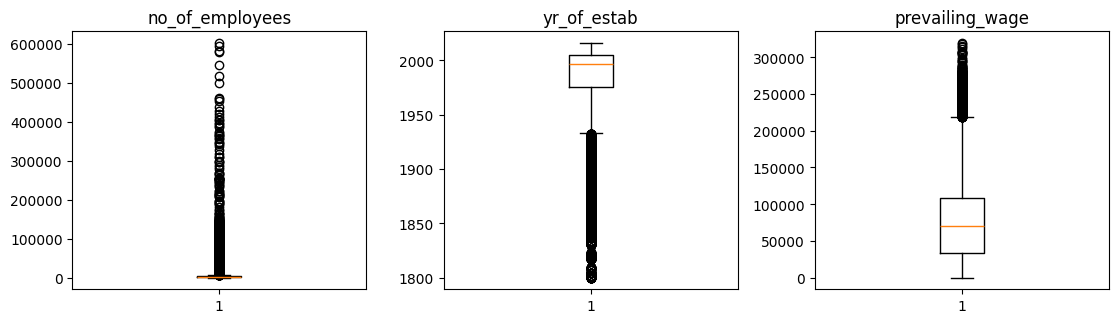

In [29]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

#### Observation 
- The dataset spans a wide range of company sizes, from small businesses to large enterprises.
- Most companies are relatively new, founded after 1950.
- Prevailing wages vary widely, with most being moderate but a few significantly high — possibly representing senior or specialized roles.

### Data Preparation for modeling

In [30]:
df["case_status"] = df["case_status"].apply(
    lambda x: 1 if str(x).strip().lower() == "certified" else 0
)

X = df.drop("case_status", axis=1)
y = df['case_status']

X = pd.get_dummies(X,drop_first=True)

#split the dataset into train and validation set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

#split the dataset into validation and test
X_val,X_test,y_val,y_test = train_test_split(
    X_val,y_val,test_size=0.1,random_state=1,stratify=y_val
)

df['case_status'].unique()

array([0, 1], dtype=int64)

In [31]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1   0.668
0   0.332
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [32]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [33]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

#### Metric selection
* The primary goal is to help shortlist candidates who are likely to be approved
* It’s okay if the model misses a few that could be certified later in manual review.
* But it’s not okay if it wrongly recommends many ineligible candidates, because that wastes time for visa officers
* Precision is the more relevant metric for this case.

In [34]:
scorer = metrics.make_scorer(metrics.precision_score)


**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [35]:
pd.Series(y_train).value_counts()


case_status
1    11913
0     5923
Name: count, dtype: int64

In [36]:
models = []

#ebsemble bagging classifiers
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))

#ensemble boosting classifier
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))

#non ensemble classifier
models.append(("dtree", DecisionTreeClassifier(random_state=1)))


results1 = []
names = [] 

print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1) 

    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring = scorer,cv=kfold)

    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train,y_train) 
    scores = precision_score(y_val, model.predict(X_val))

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.776316965904243
Random forest: 0.7717966161141449
GBM: 0.7787508627872894
Adaboost: 0.7582135666697509
Xgboost: 0.7700012547907965
dtree: 0.7427154602018234

Validation Performance:

Bagging: 0.7713783249065729
Random forest: 0.7678967533776971
GBM: 0.7710612166570716
Adaboost: 0.7568071615069004
Xgboost: 0.7695789059425423
dtree: 0.754207263064659


#### Observation 
- GBM is the best performing model with precision score of 77% in the validation set
- Bagging and XGBoost also performed well

### Model Building with Oversampled data

In [37]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=3, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [38]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  
names = [] 


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset After Oversampling:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    cv_result = cross_val_score(estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold)
    
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance After Oversampling:" "\n")

for name, model in models:
    model.fit(X_train_over,y_train_over) 
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset After Oversampling:

Bagging: 0.7685559767928162
Random forest: 0.7722344551311409
GBM: 0.7617239898593837
Adaboost: 0.7497665095647914
Xgboost: 0.7616396382817694
dtree: 0.7335831747866876

Validation Performance After Oversampling:

Bagging: 0.7753769975241953
Random forest: 0.7716584158415841
GBM: 0.7762056596253487
Adaboost: 0.766660190402176
Xgboost: 0.769061876247505
dtree: 0.7525453740593183


#### Observation 
- GBM is still the best performing model after oversampling with precision score of 77% in the validation set
- Bagging and random forest also performed well 

### Model Building with Undersampled data

In [39]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [40]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  
names = []  


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    cv_result = cross_val_score(estimator=model, X=X_train_un, y=y_train_un,scoring = scorer, cv=kfold,n_jobs =1)

    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un,y_train_un) 
    scores = precision_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.6832581175910596
Random forest: 0.6920425073211518
GBM: 0.7076890303881316
Adaboost: 0.6880884859558714
Xgboost: 0.6925084798467304
dtree: 0.6163099821610538

Validation Performance:

Bagging: 0.8063768115942029
Random forest: 0.8115445440168687
GBM: 0.8215547703180212
Adaboost: 0.8101045296167247
Xgboost: 0.8098790841265757
dtree: 0.7599787120808941


#### Observation 
- GBM is still the best performing model 
- GBM's performace has increased to 82% precision score in validation dataset
- Random forst and Bagging classifier performance also improved

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

### ADABoosting Parameter Tunning

#### Random Search CV

In [98]:
# defining model
model = AdaBoostClassifier(random_state=1)

#create Kfold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125], 
    "learning_rate": [1.0, 0.5, 0.1, 0.01],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=kfold, 
    random_state=1
)

randomized_cv.fit(X_train_over,y_train_over)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=AdaBoostClassifier(random_state=1), n_iter=50,
                   n_jobs=-2,
                   param_distributions={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=2,
                                                                             random_state=1),
                                                      DecisionTreeClassifier(max_depth=3,
                                                                             random_state=1)],
                                        'learning_rate': [1.0, 0.5, 0.1, 0.01],
                                        'n_estimators': [50, 75, 100, 125]},
                   random_state=1,
                   scoring=make_scorer(precision_score, response_method='predict'))

In [99]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.7581861432157038:


In [100]:
tuned_ada = randomized_cv.best_estimator_
tuned_ada

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=100, random_state=1)

In [101]:
tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
tuned_ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.802,0.870,0.766,0.815


In [102]:
tuned_ada_val_perf = model_performance_classification_sklearn(tuned_ada,X_val,y_val)
tuned_ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.741,0.859,0.777,0.816


#### Grid Search CV

In [103]:
# defining model
model = AdaBoostClassifier(random_state=1)

#create Kfold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    "n_estimators": [50, 75, 100, 125], 
    "learning_rate": [1.0, 0.5, 0.1, 0.01],
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scorer,
    cv=kfold,
    n_jobs=-1,
    verbose=2
)

# Fit the model
grid_search.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=AdaBoostClassifier(random_state=1), n_jobs=-1,
             param_grid={'estimator': [DecisionTreeClassifier(max_depth=1,
                                                              random_state=1),
                                       DecisionTreeClassifier(max_depth=2,
                                                              random_state=1),
                                       DecisionTreeClassifier(max_depth=3,
                                                              random_state=1)],
                         'learning_rate': [1.0, 0.5, 0.1, 0.01],
                         'n_estimators': [50, 75, 100, 125]},
             scoring=make_scorer(precision_score, response_method='predict'),
             verbose=2)

In [104]:
print("Best parameters are {} with CV score={}:" .format(grid_search.best_params_,grid_search.best_score_))

Best parameters are {'estimator': DecisionTreeClassifier(max_depth=3, random_state=1), 'learning_rate': 0.1, 'n_estimators': 100} with CV score=0.7581861432157038:


In [105]:
tuned_ada = grid_search.best_estimator_
tuned_ada

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=100, random_state=1)

In [106]:
tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
tuned_ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.802,0.870,0.766,0.815


In [107]:
tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)
tuned_ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.741,0.859,0.777,0.816


#### Observation 
- Ada Boosting with random search cv has precision of 0.777
- Ada Boosting with grid search cv has precision of 0.774
- almost the same performance

### Gradient boosting Parameter Tunning

In [108]:
# defining model
model = GradientBoostingClassifier(random_state=1)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

## Complete the code to define the hyper parameters.
param_grid={
    "n_estimators": [100, 125, 150, 175], 
    "learning_rate": [0.1, 0.05, 0.01, 0.005], 
    "subsample":[0.7, 0.8, 0.9, 1.0], 
    "max_features":["sqrt"]
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=kfold,
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=50, n_jobs=-2,
                   param_distributions={'learning_rate': [0.1, 0.05, 0.01,
                                                          0.005],
                                        'max_features': ['sqrt'],
                                        'n_estimators': [100, 125, 150, 175],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=1,
                   scoring=make_scorer(precision_score, response_method='predict'))

In [109]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 175, 'max_features': 'sqrt', 'learning_rate': 0.1} with CV score=0.7632930471327383:


In [110]:
tuned_gbm = randomized_cv.best_estimator_
tuned_gbm

GradientBoostingClassifier(max_features='sqrt', n_estimators=175,
                           random_state=1, subsample=0.9)

In [111]:
tuned_gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
tuned_gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.798,0.856,0.767,0.809


In [112]:
tuned_gbm_val_perf = model_performance_classification_sklearn(tuned_gbm,X_val,y_val)
tuned_gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.738,0.849,0.779,0.813


### XGBoost Parameter Tunning

In [93]:
# defining model
model = XGBClassifier(
    tree_method="hist",
    device="cuda",            # <-- use GPU
    predictor="gpu_predictor",# <-- GPU inference too
    eval_metric="logloss",
    random_state=1
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid={
    'n_estimators':[50,75,100,125.], 
    'subsample':[0.5, 0.7, 0.8, 1.0], 
    'gamma':[1, 3, 5, 8], 
    'colsample_bytree':[0.3, 0.5, 0.7, 1.0], 
    'colsample_bylevel':[0.3, 0.5, 0.7, 1.0],
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=kfold,
    random_state=1,
    verbose=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device='cuda',
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=Non...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bylevel': [0.3, 0.5, 0.7,
                                                              1.0],
                                        'colsample_bytree': [0.3, 0.5, 0.7,
                                                             1.0],
                                        'gamma': [1, 3, 5, 8],
                                        'n_estimators': [50, 75, 100, 125.0],
                                        'subsample': [0.5, 0.7, 0.8, 1.0]},
                   random_state=1,
                   scoring=make_scorer(precision_score, response_method='predict'),
                   verbose=1)

In [94]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1.0, 'n_estimators': 100, 'gamma': 1, 'colsample_bytree': 0.3, 'colsample_bylevel': 1.0} with CV score=0.766833194621731:


In [95]:
tuned_xgb = randomized_cv.best_estimator_
tuned_xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=1.0, colsample_bynode=None,
              colsample_bytree=0.3, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [96]:
tuned_xgb_train_perf = model_performance_classification_sklearn(
    tuned_xgb, X_train_over, y_train_over
)
tuned_xgb_train_perf

,Accuracy,Recall,Precision,F1
0,0.826,0.879,0.795,0.835


In [97]:
tuned_xgb_val_perf = model_performance_classification_sklearn(tuned_xgb,X_val,y_val)
tuned_xgb_val_perf

,Accuracy,Recall,Precision,F1
0,0.730,0.839,0.775,0.806


### Random Forest Parameter Tunning

In [119]:
# defining model
model = RandomForestClassifier(random_state=1, n_jobs=-1)

#create Kfold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# parameter distributions for RF
param_dist = {
    "n_estimators": [50, 75, 100, 125, 200, 300],
    "max_depth": [None, 4, 6, 8, 12, 16],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "bootstrap": [True, False],
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    n_jobs=-1,
    scoring=scorer,
    cv=kfold, 
    random_state=1
)

randomized_cv.fit(X_train_un,y_train_un)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 4, 6, 8, 12, 16],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5, 0.7, 1.0],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [50, 75, 100, 125, 200,
                                                         300]},
                   random_state=1,
                   scoring=make_scorer(precision_score, response_method='predict'))

In [120]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 75, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None, 'bootstrap': True} with CV score=0.7064442371049126:


In [121]:
tuned_rf = randomized_cv.best_estimator_
tuned_rf

RandomForestClassifier(max_features=0.3, min_samples_leaf=2,
                       min_samples_split=20, n_estimators=75, n_jobs=-1,
                       random_state=1)

In [126]:
tuned_rf_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
tuned_rf_train_perf

,Accuracy,Recall,Precision,F1
0,0.802,0.870,0.766,0.815


In [125]:
tuned_rf_val_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)
tuned_rf_val_perf

,Accuracy,Recall,Precision,F1
0,0.741,0.859,0.777,0.816


## Model Performance Summary and Final Model Selection

In [127]:

models_train_comp_df = pd.concat(
    [
        tuned_gbm_train_perf.T,
        tuned_xgb_train_perf.T,
        tuned_ada_train_perf.T,
        tuned_rf_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.798,0.826,0.741,0.802
Recall,0.856,0.879,0.859,0.870
Precision,0.767,0.795,0.777,0.766
F1,0.809,0.835,0.816,0.815


In [128]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        tuned_gbm_val_perf.T,
        tuned_xgb_val_perf.T, 
        tuned_ada_val_perf.T,
        tuned_rf_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    "XGBoost tuned with oversampled data",
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with oversampled data,XGBoost tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.738,0.730,0.741,0.741
Recall,0.849,0.839,0.859,0.859
Precision,0.779,0.775,0.777,0.777
F1,0.813,0.806,0.816,0.816


In [129]:
# selecting the final model by uncommenting the line corresponding to the final model chosen

final_model = tuned_gbm

In [130]:
test = model_performance_classification_sklearn(final_model, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.758,0.871,0.789,0.828


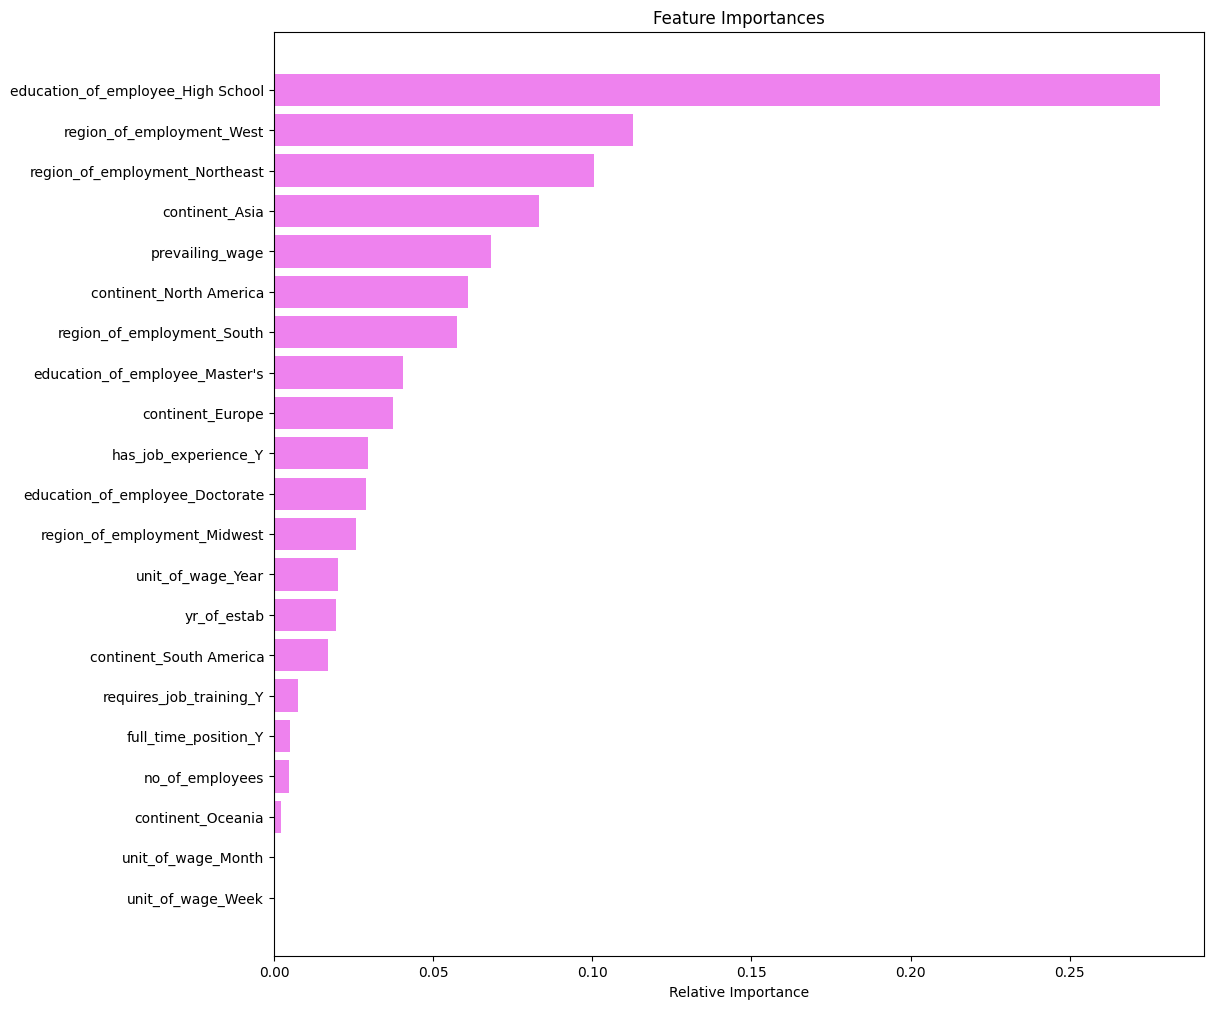

In [131]:
feature_names = X_train.columns
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Recommendations

<font size=6 color='blue'>Power Ahead</font>
___